In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Functions

In [2]:
def calc_metrics(arr_true, arr_pred):
    """Calculate regression metrics."""
    arr_true = np.array(arr_true)
    arr_pred = np.array(arr_pred)
    flt_mae = np.mean(np.abs(arr_true - arr_pred))
    flt_mape = np.mean(np.abs((arr_true - arr_pred) / np.clip(arr_true, 1, None))) * 100
    flt_rmse = np.sqrt(np.mean((arr_true - arr_pred) ** 2))
    flt_median_ae = np.median(np.abs(arr_true - arr_pred))
    flt_r2 = 1 - np.sum((arr_true - arr_pred)**2) / np.sum((arr_true - np.mean(arr_true))**2)
    return {
        'MAE': round(flt_mae, 2),
        'MAPE (%)': round(flt_mape, 2),
        'RMSE': round(flt_rmse, 2),
        'Median AE': round(flt_median_ae, 2),
        'R2': round(flt_r2, 4),
    }

#### Constants

In [3]:
str_bucket = 'assessment-alt'
str_task = '04_price_estimator'
str_dirname_output = './output'
os.makedirs(str_dirname_output, exist_ok=True)
print(f'Bucket: {str_bucket}')
print(f'Task: {str_task}')

Bucket: assessment-alt
Task: 04_price_estimator


#### Load Data

Load the same train/test splits used by the model pipeline to enable apples-to-apples comparison.

In [4]:
%%time
df_train = pd.read_csv(f's3://{str_bucket}/02_data_split/train.csv')
df_test = pd.read_csv(f's3://{str_bucket}/02_data_split/test.csv')
print(f'Train: {df_train.shape}')
print(f'Test:  {df_test.shape}')

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Train: (62407, 9)
Test:  (16058, 9)
CPU times: user 358 ms, sys: 67.9 ms, total: 426 ms
Wall time: 644 ms


#### Text Normalization

In [5]:
for df in [df_train, df_test]:
    df['subject'] = df['subject'].str.lower().str.strip()
    df['brand'] = df['brand'].str.lower().str.strip()
    df['variety'] = df['variety'].str.lower().str.strip()
    df['variety'] = df['variety'].fillna('base')
    df['card_number'] = df['card_number'].astype(str).str.lower().str.strip()
    df['grading_company'] = df['grading_company'].str.lower().str.strip()
print('Text normalization complete')
df_train.head()

Text normalization complete


,year,subject,brand,variety,card_number,date,price,grade,grading_company
0,2018,ben simmons,upper deck cdd conference goodwin champions pr...,gdwn.champ.prev.auto.,cddbs,2018-05-16,700.00,10.0,psa
1,2018,ben simmons,upper deck cdd conference goodwin champions pr...,gdwn.champ.prev.auto.,cddbs,2018-07-16,799.99,9.0,psa
2,2018,ben simmons,upper deck cdd conference goodwin champions pr...,gdwn.champ.prev.auto.,cddbs,2018-07-25,679.99,9.0,psa
3,2018,lavar ball/shanon & skip ain't,leaf,inscriptions lavar ball green,milb1,2018-08-08,56.00,9.5,bgs
4,2018,lavar ball,leaf,inscriptions lavar ball purple,milb2,2018-08-14,41.26,9.5,bgs


#### Create Card Key

Cards are fungible if (year, subject, brand, variety, card_number, grade, grading_company) are the same.

In [6]:
for df in [df_train, df_test]:
    df['str_card_key'] = (
        df['year'].astype(str) + '|' +
        df['subject'] + '|' +
        df['brand'] + '|' +
        df['variety'] + '|' +
        df['card_number'] + '|' +
        df['grade'].astype(str) + '|' +
        df['grading_company']
    )
int_unique_train = df_train['str_card_key'].nunique()
int_unique_test = df_test['str_card_key'].nunique()
print(f'Unique card keys (train): {int_unique_train:,}')
print(f'Unique card keys (test):  {int_unique_test:,}')
print(f'Avg transactions per card (train): {len(df_train)/int_unique_train:.1f}')

Unique card keys (train): 15,269
Unique card keys (test):  6,091
Avg transactions per card (train): 4.1


#### Baseline 1: Most Recent Previous Transaction

For each test transaction, find the most recent prior sale of the same card key in the training set.

In [7]:
%%time
# Get the most recent transaction for each card key in training data
df_train['date'] = pd.to_datetime(df_train['date'])
df_last_txn = df_train.sort_values('date').groupby('str_card_key')['price'].last().reset_index()
df_last_txn.columns = ['str_card_key', 'flt_pred_last_txn']

# Merge with test
df_test = df_test.merge(df_last_txn, on='str_card_key', how='left')
int_coverage_exact = df_test['flt_pred_last_txn'].notna().sum()
print(f'Exact match coverage: {int_coverage_exact:,} / {len(df_test):,} ({int_coverage_exact/len(df_test)*100:.1f}%)')

Exact match coverage: 12,625 / 16,058 (78.6%)
CPU times: user 66.6 ms, sys: 3.78 ms, total: 70.4 ms
Wall time: 69.3 ms


#### Baseline 2: Median Price Fallback

For cards with no exact match, fall back to median price of (subject, grade) from training data. If still no match, use global median.

In [8]:
# Subject + Grade median
df_subj_grade_median = df_train.groupby(['subject', 'grade'])['price'].median().reset_index()
df_subj_grade_median.columns = ['subject', 'grade', 'flt_pred_subj_grade']
df_test = df_test.merge(df_subj_grade_median, on=['subject', 'grade'], how='left')

# Subject median
df_subj_median = df_train.groupby('subject')['price'].median().reset_index()
df_subj_median.columns = ['subject', 'flt_pred_subj']
df_test = df_test.merge(df_subj_median, on='subject', how='left')

# Global median
flt_global_median = df_train['price'].median()
print(f'Global median price: ${flt_global_median:.2f}')

# Coverage
int_coverage_subj_grade = df_test['flt_pred_subj_grade'].notna().sum()
int_coverage_subj = df_test['flt_pred_subj'].notna().sum()
print(f'Subject+Grade coverage: {int_coverage_subj_grade:,} / {len(df_test):,} ({int_coverage_subj_grade/len(df_test)*100:.1f}%)')
print(f'Subject coverage: {int_coverage_subj:,} / {len(df_test):,} ({int_coverage_subj/len(df_test)*100:.1f}%)')

Global median price: $119.99
Subject+Grade coverage: 15,929 / 16,058 (99.2%)
Subject coverage: 16,029 / 16,058 (99.8%)


#### Combine Baselines

Priority: exact match > subject+grade median > subject median > global median

In [9]:
df_test['flt_pred_combined'] = df_test['flt_pred_last_txn']
df_test['str_method'] = 'exact_match'

# Fill missing with subject+grade median
mask_missing = df_test['flt_pred_combined'].isna()
df_test.loc[mask_missing, 'flt_pred_combined'] = df_test.loc[mask_missing, 'flt_pred_subj_grade']
df_test.loc[mask_missing, 'str_method'] = 'subject_grade_median'

# Fill remaining with subject median
mask_missing = df_test['flt_pred_combined'].isna()
df_test.loc[mask_missing, 'flt_pred_combined'] = df_test.loc[mask_missing, 'flt_pred_subj']
df_test.loc[mask_missing, 'str_method'] = 'subject_median'

# Fill remaining with global median
mask_missing = df_test['flt_pred_combined'].isna()
df_test.loc[mask_missing, 'flt_pred_combined'] = flt_global_median
df_test.loc[mask_missing, 'str_method'] = 'global_median'

print('Method distribution:')
print(df_test['str_method'].value_counts())
print(f'\nTotal coverage: {df_test["flt_pred_combined"].notna().sum():,} / {len(df_test):,} (100%)')

Method distribution:
str_method
exact_match             12625
subject_grade_median     3304
subject_median            100
global_median              29
Name: count, dtype: int64

Total coverage: 16,058 / 16,058 (100%)


#### Evaluate Baselines

In [10]:
list_dict_metrics = []

# Exact match only
df_exact = df_test[df_test['flt_pred_last_txn'].notna()]
if len(df_exact) > 0:
    dict_exact = calc_metrics(df_exact['price'], df_exact['flt_pred_last_txn'])
    dict_exact['Method'] = 'Exact Match Only'
    dict_exact['N'] = len(df_exact)
    list_dict_metrics.append(dict_exact)

# Subject+Grade median (for all that have it)
df_sg = df_test[df_test['flt_pred_subj_grade'].notna()]
if len(df_sg) > 0:
    dict_sg = calc_metrics(df_sg['price'], df_sg['flt_pred_subj_grade'])
    dict_sg['Method'] = 'Subject+Grade Median'
    dict_sg['N'] = len(df_sg)
    list_dict_metrics.append(dict_sg)

# Combined (all test)
dict_combined = calc_metrics(df_test['price'], df_test['flt_pred_combined'])
dict_combined['Method'] = 'Combined (all fallbacks)'
dict_combined['N'] = len(df_test)
list_dict_metrics.append(dict_combined)

df_metrics = pd.DataFrame(list_dict_metrics)
df_metrics = df_metrics[['Method', 'N', 'MAE', 'MAPE (%)', 'RMSE', 'Median AE', 'R2']]
print(df_metrics.to_string(index=False))

                  Method     N    MAE  MAPE (%)     RMSE  Median AE      R2
        Exact Match Only 12625 158.72    121.71   822.06      39.00  0.6375
    Subject+Grade Median 15929 620.53    237.57 33153.11      65.00 -0.0001
Combined (all fallbacks) 16058 571.43    147.78 33006.38      40.49  0.0007


#### Coverage Analysis

str_method
exact_match             12625
subject_grade_median     3304
subject_median            100
global_median              29
Name: count, dtype: int64


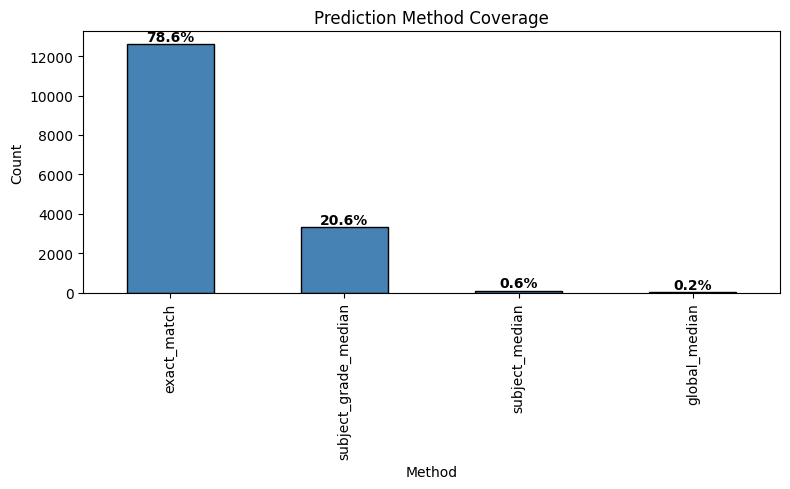

In [11]:
sr_coverage = df_test['str_method'].value_counts()
print(sr_coverage)

fig, ax = plt.subplots(figsize=(8, 5))
sr_coverage.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Prediction Method Coverage')
ax.set_xlabel('Method')
ax.set_ylabel('Count')
for i, (idx, val) in enumerate(sr_coverage.items()):
    ax.text(i, val + len(df_test)*0.01, f'{val/len(df_test)*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/coverage.png', dpi=150, bbox_inches='tight')
plt.show()

#### Error Analysis

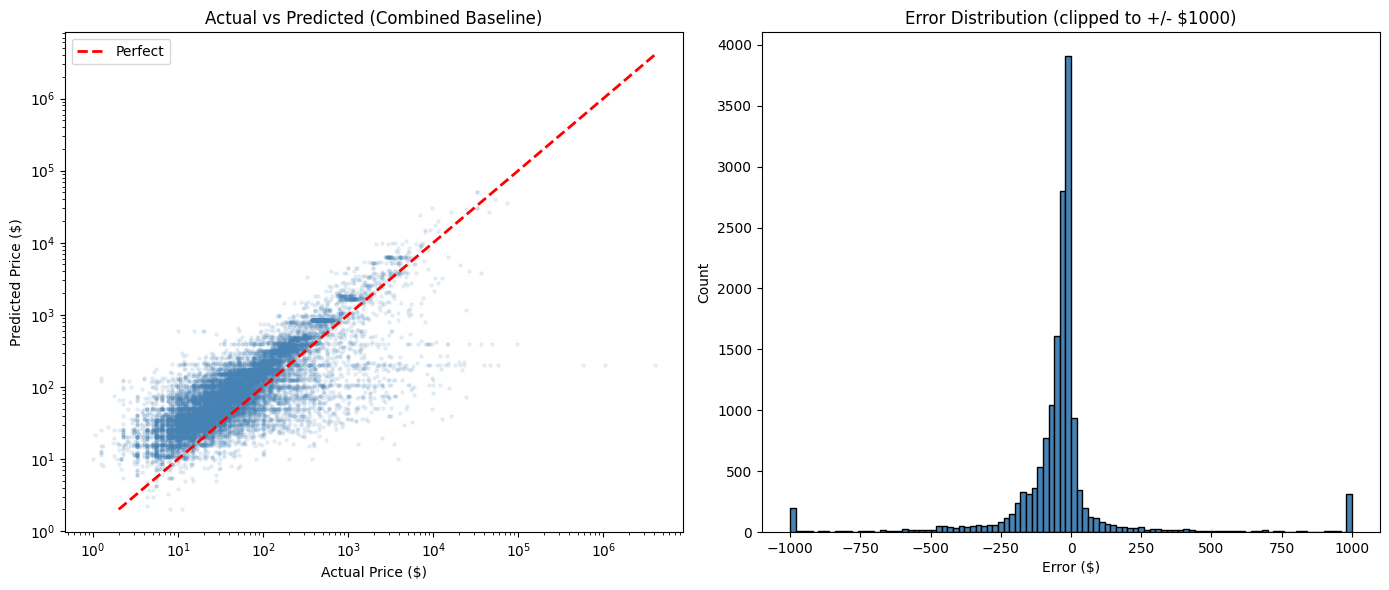

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted scatter (log scale)
axes[0].scatter(df_test['price'], df_test['flt_pred_combined'], alpha=0.1, s=5, color='steelblue')
flt_min = max(df_test['price'].min(), df_test['flt_pred_combined'].min(), 1)
flt_max = max(df_test['price'].max(), df_test['flt_pred_combined'].max())
axes[0].plot([flt_min, flt_max], [flt_min, flt_max], 'r--', linewidth=2, label='Perfect')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Actual vs Predicted (Combined Baseline)')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend()

# Error distribution
arr_errors = df_test['price'] - df_test['flt_pred_combined']
axes[1].hist(np.clip(arr_errors, -1000, 1000), bins=100, color='steelblue', edgecolor='black')
axes[1].set_title('Error Distribution (clipped to +/- $1000)')
axes[1].set_xlabel('Error ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

#### Save Results

In [13]:
df_metrics.to_csv(f'{str_dirname_output}/baseline_metrics.csv', index=False)
print(f'Saved baseline_metrics.csv to {str_dirname_output}')

Saved baseline_metrics.csv to ./output


#### Takeaways

- **Exact match baseline** (most recent previous transaction) provides the strongest predictions where available, but limited by coverage
- **Subject+Grade median** is a reasonable fallback for cards not previously seen
- **Combined approach** achieves 100% coverage by cascading through fallback strategies
- **Median Absolute Error** is more robust than MAE for this skewed price distribution
- This non-ML baseline establishes the floor that our model needs to beat
- **Same splits as model pipeline** - train/test data loaded from 02_data_split for apples-to-apples comparison with the XGBoost model in 05_model